In [1]:
# Make the notebook wider 
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

%load_ext autoreload
%autoreload 2

<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=9><b>Step 1: Download the Dataset</b></font>
</div>
<br>

In this step, we load the dataset from an Excel file that contains two sheets:

<ul>
  <li><b>data_combined</b>: used as the <b>training set</b></li>
  <li><b>data_demonstrator</b>: used as the <b>test set</b></li>
</ul>

Each row corresponds to a packaged integrated circuit (IC), and the objective is to predict the <span style="color:#003366"><b>die area</b></span>.

<br>

<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=5><b>Feature Descriptions</b></font>
</div>
<br>

<table style="width:45%">
    <thead>
        <tr>
            <th style="width:20%">Feature</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><code>P_type</code></td>
            <td>Package type (e.g., BGA, WLP), aggregated version</td>
        </tr>
        <tr>
            <td><code>PinCount</code></td>
            <td>Total number of pins on the package</td>
        </tr>
        <tr>
            <td><code>P_area</code></td>
            <td>Package area in mm² (length × width)</td>
        </tr>
        <tr>
            <td><code>M</code></td>
            <td>Package mass in grams</td>
        </tr>
        <tr>
            <td><code>Die_area</code></td>
            <td><b>Target variable</b>: Die area in mm²</td>
        </tr>
    </tbody>
</table>


In [2]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
from Utils.loadData import load_data

df_train, df_test = load_data("Data/dataset.xlsx")

df_train = df_train.dropna(subset=["Die_area"])
df_test  = df_test.dropna(subset=["Die_area"])

# ------------------------------------
# uncomment to see dataset description
# ------------------------------------
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 0 to 551
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   P_type     491 non-null    object 
 1   Pin_count  459 non-null    float64
 2   P_area     491 non-null    float64
 3   M          297 non-null    float64
 4   Die_area   491 non-null    float64
dtypes: float64(4), object(1)
memory usage: 23.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   P_type     150 non-null    object 
 1   Pin_count  148 non-null    float64
 2   P_area     148 non-null    float64
 3   M          148 non-null    float64
 4   Die_area   150 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<br><br>
<div style="border: 2px solid steelblue; border-radius: 8px; padding: 15px; background-color: #f0f8ff; font-family: Arial, sans-serif;">

The data summary reveals notable differences in feature completeness between the training and test sets:

<ul>
  <li> All selected features are fully available in the <b>test set</b> (148 rows).</li>
  <li> In contrast, the <b>training set</b> (491 rows) has <b>missing values</b> in several features, most notably in the <code>M</code> (mass) column:
    <ul>
      <li>Only <b>297 out of 491</b> training samples contain a valid mass value.</li>
      <li>That means nearly <b>40% of the training samples lack mass information</b></li>
    </ul>
  </li>
</ul>

</div>
<br><br>


<br><br>
<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=9><b>Step 2: Exploratory Data Analysis</b></font>
</div>
<br>

This section is dedicated to a visual comparison of feature distributions between the <b>training</b> and <b>test</b> datasets.

By analyzing and contrasting distributions of both input features and the target variable (<code>Die_area</code>), we aim to:
<ul>
    <li>Detect potential covariate shift (distribution mismatch)</li>
    <li>Understand feature relevance and variability</li>
    <li>Check whether certain features require normalization or preprocessing</li>
</ul>


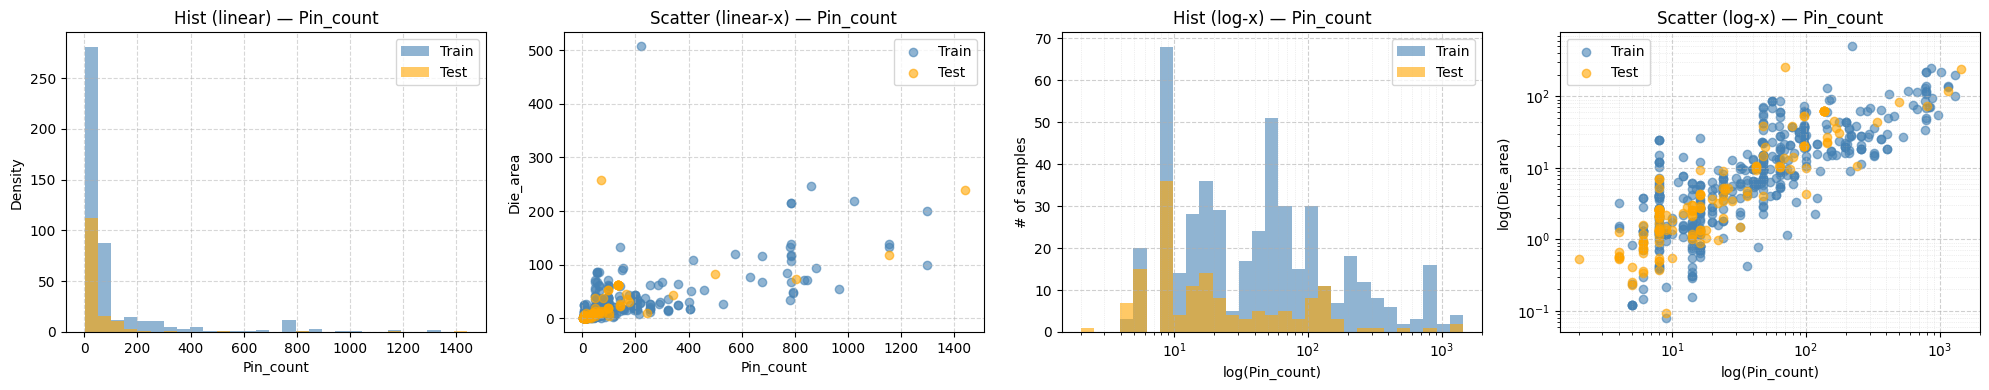

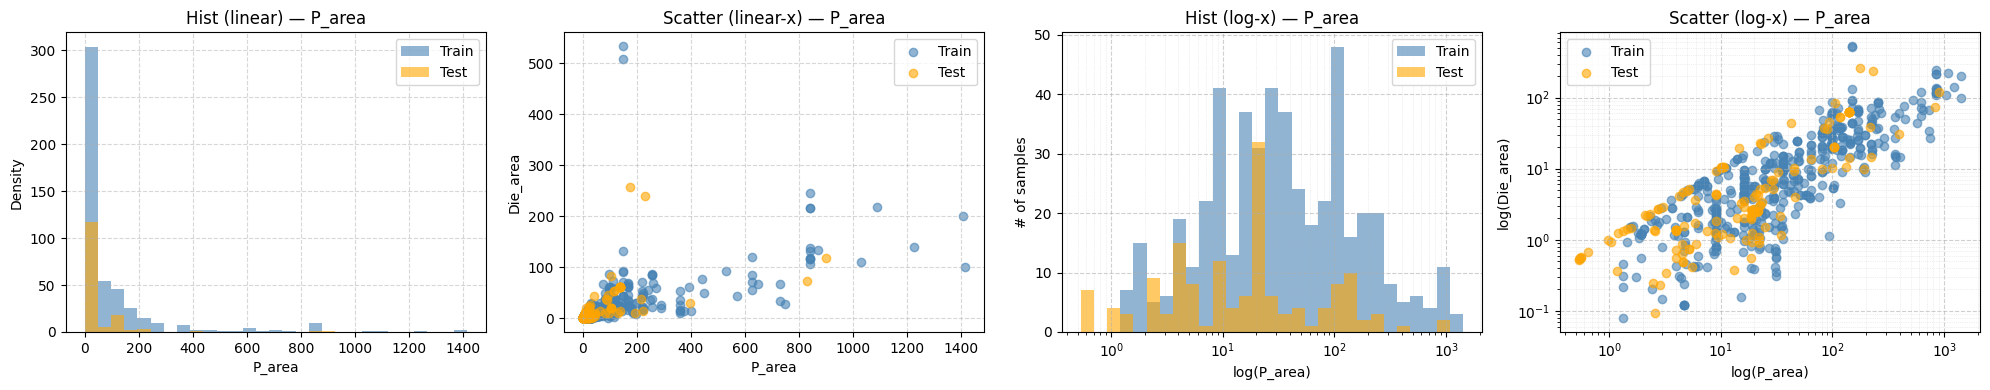

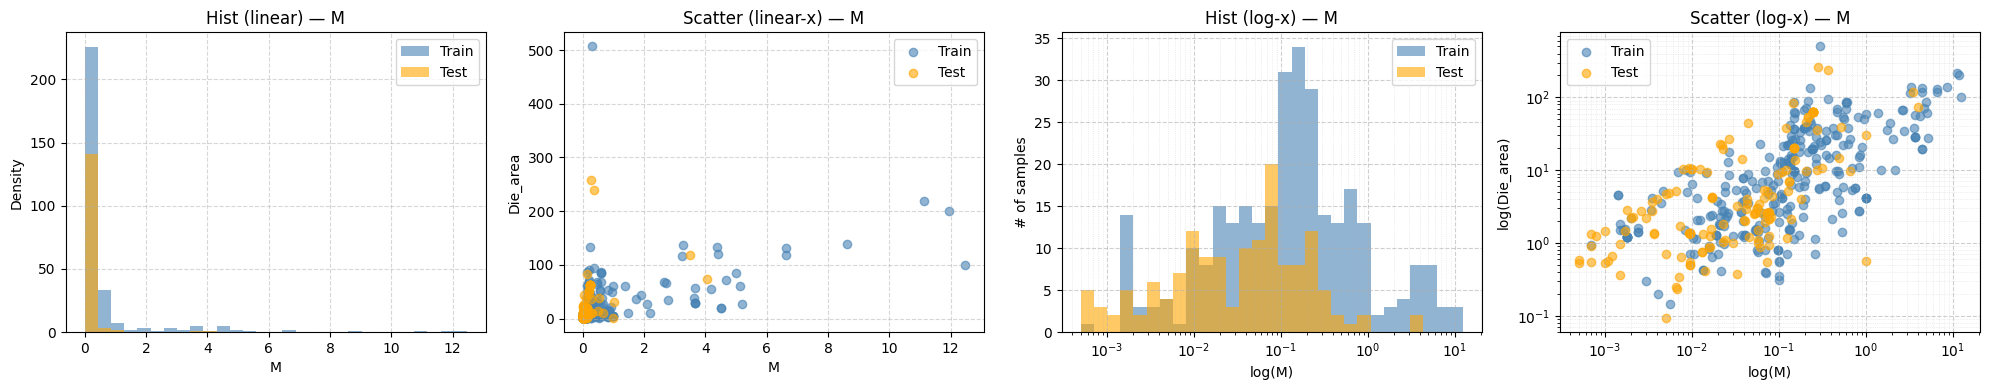

In [3]:
from MakeGraphs.EDA import *

plot_numeric_distributions_grid(df_train, df_test)

<br><br>
<div style="border: 2px solid steelblue; border-radius: 8px; padding: 15px; background-color: #f0f8ff; font-family: Arial, sans-serif;">

The variable <code>M</code> (mass) exhibits a <b>heavy-tailed distribution</b> in both the training and test sets.

This suggests that a <b>log transformation of the feature <code>M</code></b> could be beneficial for the modeling step, especially for:
<ul>
  <li>Reducing skewness,</li>
  <li>Improving the visibility of patterns,</li>
  <li>Facilitating better learning in regression models (especially linear ones).</li>
</ul>
Similarly, the features <code>PinCount</code> and <code>P_area</code> also display skewed distributions and could be considered for log-transformation.
</div>
<br><br>


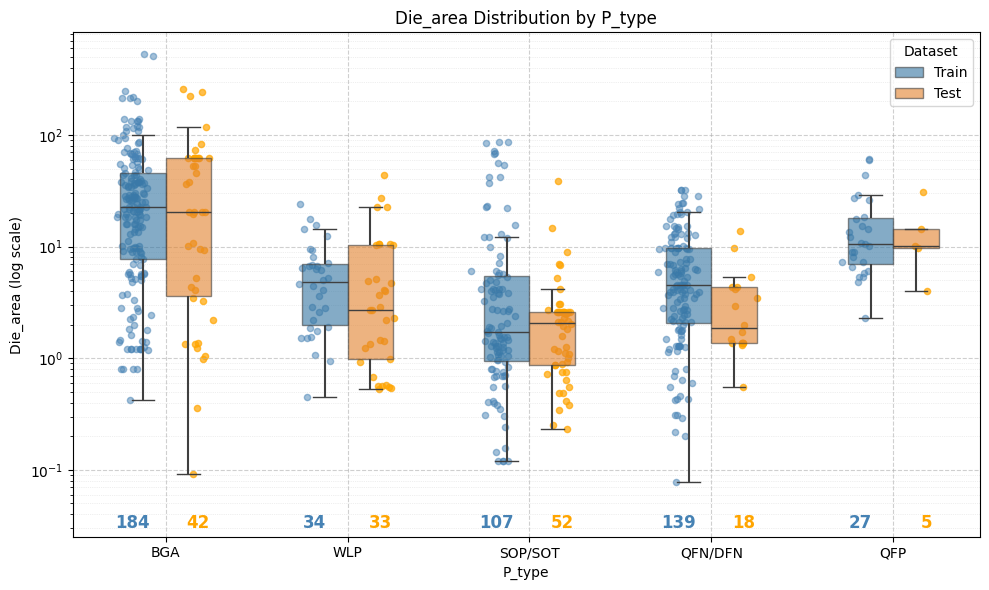

ANOVA F-statistic: 17.856, p-value: 1.0880e-13


In [4]:
from scipy.stats import f_oneway

plot_box_strip_by_ptype(df_train, df_test, log=True)

def compute_anova_correlation(df, cat_col="P_type", target_col="Die_area"):
    groups = [group[target_col].dropna() for _, group in df.groupby(cat_col)]
    stat, pval = f_oneway(*groups)
    return stat, pval

stat, pval = compute_anova_correlation(df_train, "P_type", "Die_area")
print(f"ANOVA F-statistic: {stat:.3f}, p-value: {pval:.4e}")

<br><br>

<div style="border: 2px solid steelblue; border-radius: 8px; padding: 15px; background-color: #f0f8ff; font-family: Arial, sans-serif;">

The categorical variable <b>P_type</b> is statistically associated with the continuous target variable <b>Die area</b>. <br>
F-statistic = 14.279:
<ul>
  <li>This high value indicates that the <b>variation between group means</b> (i.e., the average <code>Die area</code> for each <code>P_type</code>) is much larger than the variation within the groups.</li>
  <li>Therefore, we have strong evidence that <span style="color:#003366"><b>P_type is statistically associated with the target Die area</b></span>.</li>
</ul>

<div style="background-color: #ffffff; padding: 12px; border-left: 5px solid #003366; margin-top: 10px;">
  ⚠️ <b>Note:</b> ANOVA tells us that at least one group mean is different, but it does <i>not</i> indicate which groups differ from each other.
</div>

</div>
<br><br>

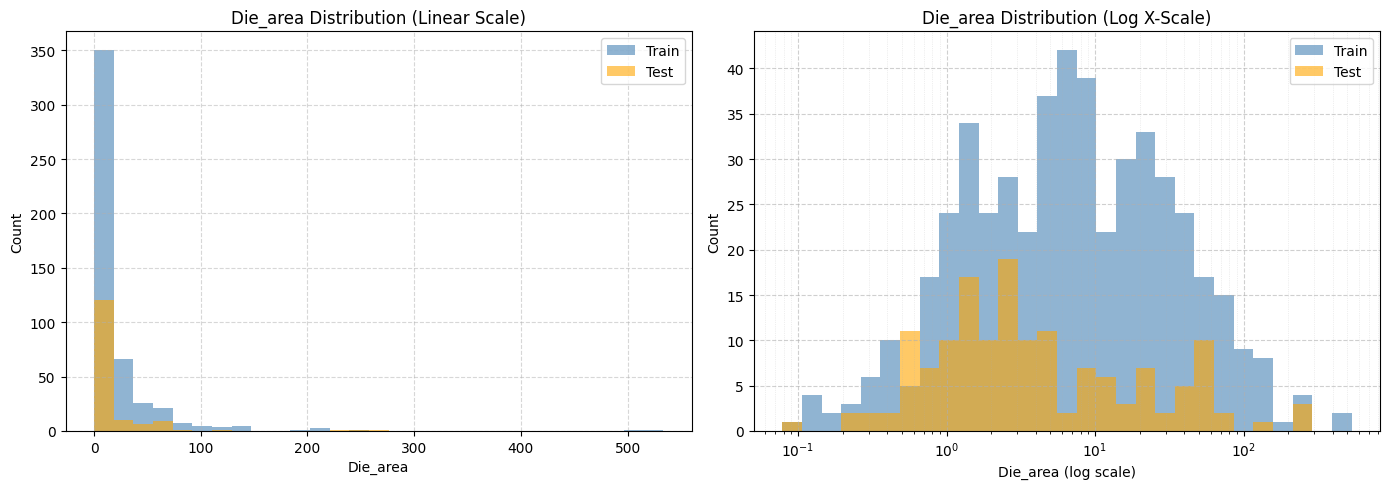

In [5]:
plot_Die_area_distribution(df_train, df_test)

<br><br>

<div style="border: 2px solid steelblue; border-radius: 8px; padding: 15px; background-color: #f0f8ff; font-family: Arial, sans-serif;">

The distributions are not identical and the test set distribution is more dense on the left while train set distribution is more dense on the right.
    
<div style="background-color: #ffffff; padding: 12px; border-left: 5px solid #003366; margin-top: 10px;">
  ⚠️ <b>Note:</b> This suggests a <b>distribution shift</b> between the two sets, which could affect the model's generalization.
</div>

</div>
<br><br>


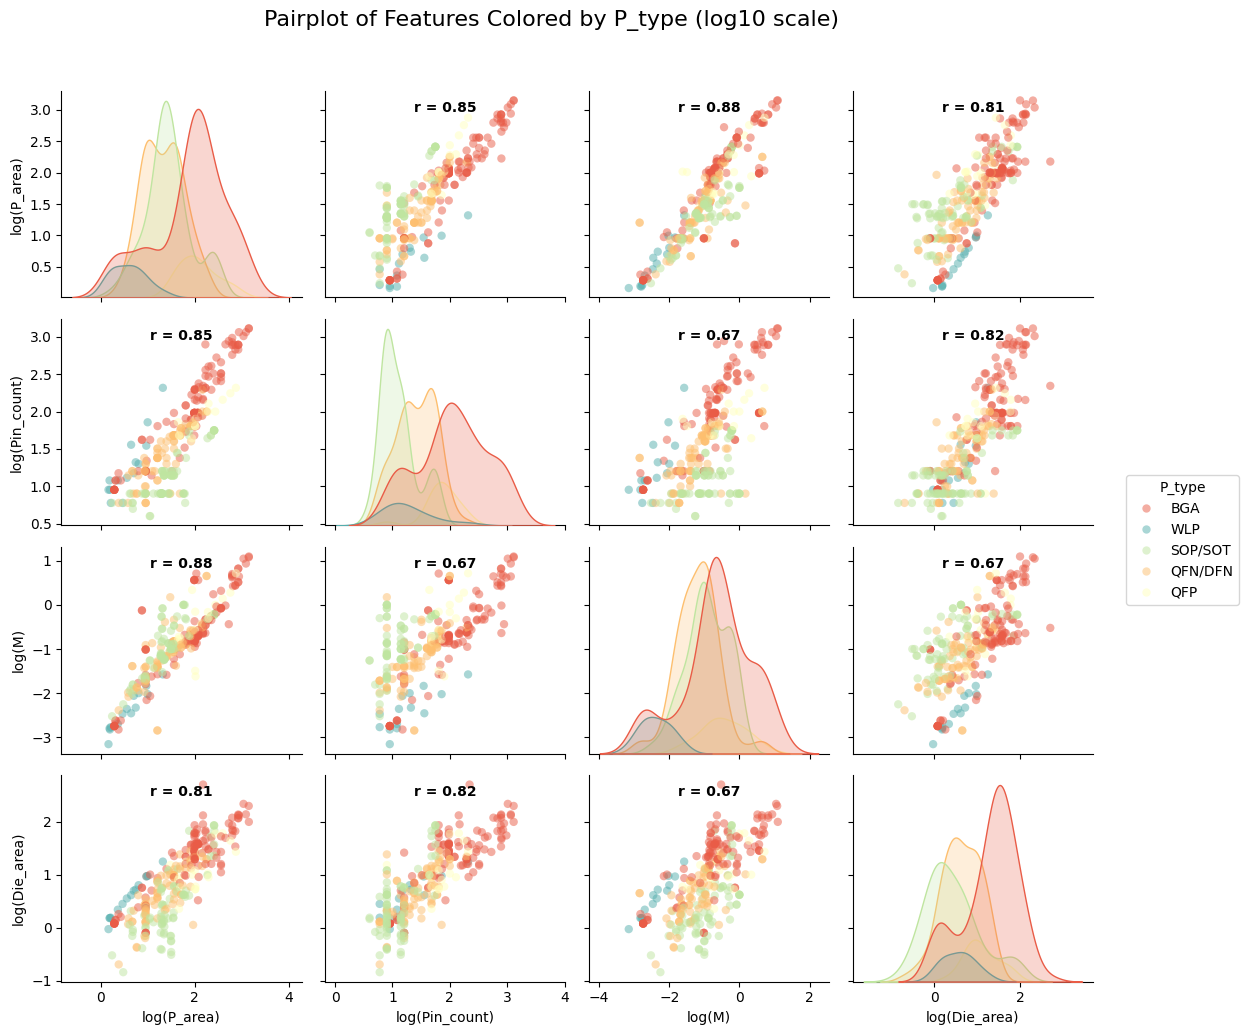

In [6]:
features = ["P_area", "Pin_count", "M", "Die_area"]  
plot_pairplot_with_correlation(df_train, features, log_log=True)

<br><br>

<div style="border: 2px solid steelblue; border-radius: 8px; padding: 15px; background-color: #f0f8ff; font-family: Arial, sans-serif;">

The pairwise scatterplots and correlation values reveal the following:

<ul>
  <li><code>P_area</code> is less linearly correlated with <code>M</code> than with other variables. 
</ul>


</div>
<br><br>
